<a href="https://colab.research.google.com/github/Chandrani45/AI-COURSE-RECOMMENDER-PROJECT-WORK-/blob/main/Chandrani_Sengupta_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOADING THE LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 9.3 MB/s eta 0:00:00


MODULE 0
Loading Groq

In [3]:
import os
from groq import Groq

In [4]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [5]:
client = Groq()

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "system", "content": "You are a concise assistant."},
        {"role": "user", "content": "Explain why Groq's inference is fast in 3 sentences."},
    ],
)

print(response.choices[0].message.content)

Groq's inference is fast due to its tensor processing unit (TPU) architecture, which is specifically designed for high-performance machine learning computations. This architecture allows for high-bandwidth memory access and efficient data processing, resulting in significant speedups for inference workloads. Additionally, Groq's compiler and software stack are optimized to minimize overhead and maximize throughput, further contributing to its fast inference capabilities.


LOADING THE COURSE DATASET

In [6]:
course=pd.read_csv('/content/coursera_course_dataset_v3.csv')

PRINTING THE FIRST 5 ROWS

In [7]:
course.head()

,Unnamed: 0,Title,Organization,Skills,Ratings,course_url,course_students_enrolled,course_description,Review Count,Difficulty,Type,Duration
0,0,Google Cybersecurity,Google,"Network Security, Python Programming, Linux, ...",4.8,https://www.coursera.org/professional-certific...,"700,909",Google Cloud Fundamentals: Core Infrastructure...,20K,Beginner,Professional Certificate,3 - 6 Months
1,1,Google Data Analytics,Google,"Data Analysis, R Programming, SQL, Business C...",4.8,https://www.coursera.org/professional-certific...,"229,865",Prepare for a new career in the high-growth fi...,137K,Beginner,Professional Certificate,3 - 6 Months
2,3,Google Project Management:,Google,"Project Management, Strategy and Operations, ...",4.8,https://www.coursera.org/professional-certific...,"29,702",Prepare-se para uma nova carreira no campo de ...,100K,Beginner,Professional Certificate,3 - 6 Months
3,4,IBM Data Science,IBM,"Python Programming, Data Science, Machine Lea...",4.6,https://www.coursera.org/professional-certific...,"239,622",Prepare for a career in the high-growth field ...,120K,Beginner,Professional Certificate,3 - 6 Months
4,5,Google Digital Marketing & E-commerce,Google,"Digital Marketing, Marketing, Marketing Manag...",4.8,https://www.coursera.org/professional-certific...,"384,238",This course is the eighth course in the Google...,23K,Beginner,Professional Certificate,3 - 6 Months


We drop the unnamed column as it is of no use

In [8]:
course.rename(columns={'Unnamed: 0':'Course_id'},inplace=True)

In [9]:
course.head()

,Course_id,Title,Organization,Skills,Ratings,course_url,course_students_enrolled,course_description,Review Count,Difficulty,Type,Duration
0,0,Google Cybersecurity,Google,"Network Security, Python Programming, Linux, ...",4.8,https://www.coursera.org/professional-certific...,"700,909",Google Cloud Fundamentals: Core Infrastructure...,20K,Beginner,Professional Certificate,3 - 6 Months
1,1,Google Data Analytics,Google,"Data Analysis, R Programming, SQL, Business C...",4.8,https://www.coursera.org/professional-certific...,"229,865",Prepare for a new career in the high-growth fi...,137K,Beginner,Professional Certificate,3 - 6 Months
2,3,Google Project Management:,Google,"Project Management, Strategy and Operations, ...",4.8,https://www.coursera.org/professional-certific...,"29,702",Prepare-se para uma nova carreira no campo de ...,100K,Beginner,Professional Certificate,3 - 6 Months
3,4,IBM Data Science,IBM,"Python Programming, Data Science, Machine Lea...",4.6,https://www.coursera.org/professional-certific...,"239,622",Prepare for a career in the high-growth field ...,120K,Beginner,Professional Certificate,3 - 6 Months
4,5,Google Digital Marketing & E-commerce,Google,"Digital Marketing, Marketing, Marketing Manag...",4.8,https://www.coursera.org/professional-certific...,"384,238",This course is the eighth course in the Google...,23K,Beginner,Professional Certificate,3 - 6 Months


In [10]:
course.columns

Index(['Course_id', 'Title', 'Organization', 'Skills', 'Ratings', 'course_url',
       'course_students_enrolled', 'course_description', 'Review Count',
       'Difficulty', 'Type', 'Duration'],
      dtype='object')

In [11]:
course.columns=course.columns.str.lower()


In [12]:
course.head()

,course_id,title,organization,skills,ratings,course_url,course_students_enrolled,course_description,review count,difficulty,type,duration
0,0,Google Cybersecurity,Google,"Network Security, Python Programming, Linux, ...",4.8,https://www.coursera.org/professional-certific...,"700,909",Google Cloud Fundamentals: Core Infrastructure...,20K,Beginner,Professional Certificate,3 - 6 Months
1,1,Google Data Analytics,Google,"Data Analysis, R Programming, SQL, Business C...",4.8,https://www.coursera.org/professional-certific...,"229,865",Prepare for a new career in the high-growth fi...,137K,Beginner,Professional Certificate,3 - 6 Months
2,3,Google Project Management:,Google,"Project Management, Strategy and Operations, ...",4.8,https://www.coursera.org/professional-certific...,"29,702",Prepare-se para uma nova carreira no campo de ...,100K,Beginner,Professional Certificate,3 - 6 Months
3,4,IBM Data Science,IBM,"Python Programming, Data Science, Machine Lea...",4.6,https://www.coursera.org/professional-certific...,"239,622",Prepare for a career in the high-growth field ...,120K,Beginner,Professional Certificate,3 - 6 Months
4,5,Google Digital Marketing & E-commerce,Google,"Digital Marketing, Marketing, Marketing Manag...",4.8,https://www.coursera.org/professional-certific...,"384,238",This course is the eighth course in the Google...,23K,Beginner,Professional Certificate,3 - 6 Months


In [13]:
#print rows and columns
course.shape

(623, 12)

The data has 623 rows and 11 columns

In [14]:
role_skills={'Data Scientist': ['python', 'statistics', 'machine learning', 'sql',
                           'data visualization', 'deep learning'], 'Data Analyst': ['excel', 'sql', 'statistics', 'data visualization', 'python'], 'ML Engineer':['python', 'machine learning', 'deep learning', 'sql', 'cloud'],'Data Engineer': ['python','sql', 'data wrangling', 'cloud', 'big data', 'apis'], 'Business Analyst': ['excel', 'sql', 'statistics', 'data visualization',
                           'communication'],'BI Developer': ['sql', 'data visualization', 'excel', 'statistics', 'power bi'],'AI Researcher':['python', 'deep learning', 'machine learning',
                           'mathematics', 'nlp'], 'Backend Developer': ['python', 'sql', 'apis', 'cloud', 'git'],'MLOps Engineer':['python', 'machine learning', 'cloud', 'docker', 'mlops'], 'NLP Engineer':['python', 'machine learning', 'deep learning', 'nlp',
                           'statistics']



}

In [15]:
role_skills['Data Scientist']

['python',
 'statistics',
 'machine learning',
 'sql',
 'data visualization',
 'deep learning']

In [16]:
course.isnull().sum()

,0
course_id,0
title,0
organization,0
skills,0
ratings,0
course_url,220
course_students_enrolled,236
course_description,221
review count,0
difficulty,0


In [17]:
course.duplicated().sum()

np.int64(0)

No duplicates as such

In [18]:
course.drop(columns=['organization','ratings','course_url' ,	'course_students_enrolled' ,'course_description', 'review count','difficulty','type','duration'],axis=1,inplace=True)

In [19]:
course.isnull().sum()

,0
course_id,0
title,0
skills,0


In [20]:
course.head()

,course_id,title,skills
0,0,Google Cybersecurity,"Network Security, Python Programming, Linux, ..."
1,1,Google Data Analytics,"Data Analysis, R Programming, SQL, Business C..."
2,3,Google Project Management:,"Project Management, Strategy and Operations, ..."
3,4,IBM Data Science,"Python Programming, Data Science, Machine Lea..."
4,5,Google Digital Marketing & E-commerce,"Digital Marketing, Marketing, Marketing Manag..."


In [21]:
course.shape

(623, 3)

In [22]:
#cleaning the skills dataset
import re
def clean(text):
  return re.sub(r'[^a-z0-9]','',text.str.lower())
  return re.sub(r'\s+',"",text).strip()

In [23]:
import re

def clean(s):
    s = re.sub(r"[^a-z0-9 ]", " ", str(s).lower())
    return re.sub(r"\s+", " ", s).strip()

# build the search text from Title + Skills  (note the " " between them)
course['text'] = (course['title'] + " " + course['skills']).apply(clean)

# keep a clean LIST of skills — M6 needs this
course['skills'] = course['skills'].fillna("").apply(
    lambda s: [x.strip().lower() for x in str(s).split(",") if x.strip()])

course[['course_id', 'title', 'skills', 'text']].head(3)

,course_id,title,skills,text
0,0,Google Cybersecurity,"[network security, python programming, linux, ...",google cybersecurity network security python p...
1,1,Google Data Analytics,"[data analysis, r programming, sql, business c...",google data analytics data analysis r programm...
2,3,Google Project Management:,"[project management, strategy and operations, ...",google project management project management s...


In [24]:
course.head()

,course_id,title,skills,text
0,0,Google Cybersecurity,"[network security, python programming, linux, ...",google cybersecurity network security python p...
1,1,Google Data Analytics,"[data analysis, r programming, sql, business c...",google data analytics data analysis r programm...
2,3,Google Project Management:,"[project management, strategy and operations, ...",google project management project management s...
3,4,IBM Data Science,"[python programming, data science, machine lea...",ibm data science python programming data scien...
4,5,Google Digital Marketing & E-commerce,"[digital marketing, marketing, marketing manag...",google digital marketing e commerce digital ma...


In [25]:
course['text'].iloc[0]

'google cybersecurity network security python programming linux cloud computing algorithms audit computer programming computer security incident management cryptography databases leadership and management network architecture risk management sql'

In [26]:
target_role = input('Enter a role: ').strip()
assert target_role in role_skills, f"'{target_role}' is not in the role list. Pick one of: {list(role_skills)}"

Enter a role: Data Scientist


In [27]:
target_role

'Data Scientist'

In [28]:
current_skills = [s.strip().lower() for s in input('Enter your current skills (comma-separated): ').split(",") if s.strip()]
have = set(current_skills)


Enter your current skills (comma-separated): python


In [29]:
current_skills

['python']

In [30]:
skill_gap = [s for s in role_skills[target_role] if s.lower() not in have]
query_text = " ".join(skill_gap)
print("skill_gap:", skill_gap)

skill_gap: ['statistics', 'machine learning', 'sql', 'data visualization', 'deep learning']


In [31]:
query_text

'statistics machine learning sql data visualization deep learning'

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
tfidf=TfidfVectorizer(stop_words='english')

In [34]:
course_vector=tfidf.fit_transform(course['text']).toarray()

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

In [36]:
def recommend(query_text):
  query_vector=tfidf.transform([query_text])
  similarity=cosine_similarity(course_vector,query_vector).flatten()
  course_list=course.copy()
  course_list['score']=similarity
  course_list=course_list.sort_values(by='score',ascending=False)
  return course_list.head(10)

In [37]:
result=recommend(query_text)

In [38]:
result

,course_id,title,skills,text,score
194,200,Machine Learning on Google Cloud,"[machine learning, applied machine learning, g...",machine learning on google cloud machine learn...,0.642587
7,9,Machine Learning,"[machine learning, machine learning algorithms...",machine learning machine learning machine lear...,0.635728
93,97,IBM Machine Learning,"[machine learning, machine learning algorithms...",ibm machine learning machine learning machine ...,0.629923
519,525,Applying Machine Learning to your Data with Go...,"[applied machine learning, big data, cloud com...",applying machine learning to your data with go...,0.618981
288,294,Deep Neural Networks with PyTorch,"[human learning, machine learning, deep learni...",deep neural networks with pytorch human learni...,0.614771
408,414,Introduction to Artificial Intelligence (AI),"[algorithms, applied machine learning, artific...",introduction to artificial intelligence ai alg...,0.606391
149,155,"Unsupervised Learning, Recommenders, Reinforce...","[algorithms, machine learning, machine learnin...",unsupervised learning recommenders reinforceme...,0.598838
87,91,Advanced Learning Algorithms,"[applied machine learning, machine learning, m...",advanced learning algorithms applied machine l...,0.595222
39,43,IBM AI Engineering,"[machine learning, deep learning, artificial n...",ibm ai engineering machine learning deep learn...,0.591767
100,105,IBM Introduction to Machine Learning,"[machine learning, machine learning algorithms...",ibm introduction to machine learning machine l...,0.590942


In [39]:
from sentence_transformers import SentenceTransformer,util

In [40]:
model=SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [41]:
course_embedding=model.encode(course['text'].tolist(),convert_to_tensor=False)

In [42]:
course_embedding

array([[-0.02628145, -0.04907638, -0.03646369, ...,  0.03205734,
         0.07008975, -0.02057038],
       [-0.01061211, -0.0056325 ,  0.00819515, ...,  0.00249461,
        -0.03123419, -0.0202965 ],
       [ 0.00933923, -0.01001344,  0.02373884, ..., -0.03201455,
        -0.01815793,  0.05538497],
       ...,
       [-0.00096758, -0.01760929, -0.02287252, ...,  0.00066167,
         0.02673219, -0.0455847 ],
       [-0.015496  , -0.01349185, -0.06570505, ...,  0.01464329,
         0.01539993,  0.03375338],
       [-0.06873778,  0.03724859, -0.08187516, ...,  0.04749686,
         0.13106026,  0.00676194]], dtype=float32)

In [68]:
def recommend2(query_text):
  query_vector2=model.encode([query_text],convert_to_tensor=False)
  similarity=cosine_similarity(course_embedding,query_vector2).flatten()
  course_list=course.copy()
  course_list['score_embedding']=similarity
  course_list=course_list.sort_values(by='score_embedding',ascending=False)
  return course_list.head(10)

In [69]:
result_embedding=recommend2(query_text)

In [70]:
result_embedding

,course_id,title,skills,text,score_embedding
366,372,Data Analytics for Lean Six Sigma,"[probability & statistics, data visualization,...",data analytics for lean six sigma probability ...,0.525871
297,303,From Data to Insights with Google Cloud,"[google cloud platform, cloud computing, sql, ...",from data to insights with google cloud google...,0.512695
214,220,Share Data Through the Art of Visualization,"[business communication, data analysis, data v...",share data through the art of visualization bu...,0.504352
345,351,1. 基礎知識：データはあらゆるところにある,"[data analysis, business analysis, data visual...",1 data analysis business analysis data visuali...,0.498769
420,426,Understanding and Visualizing Data with Python,"[basic descriptive statistics, data analysis, ...",understanding and visualizing data with python...,0.491735
48,52,"Foundations: Data, Data, Everywhere","[data analysis, sql, data visualization, busin...",foundations data data everywhere data analysis...,0.491105
412,418,"Sequences, Time Series and Prediction","[machine learning, forecasting, tensorflow, ap...",sequences time series and prediction machine l...,0.480311
23,27,Data Analysis and Visualization Foundations,"[microsoft excel, data visualization, spreadsh...",data analysis and visualization foundations mi...,0.475694
379,385,"Decisions, Decisions: Dashboards and Reports","[business intelligence, data model, data visua...",decisions decisions dashboards and reports bus...,0.475412
143,149,Introduction to Data Analytics,"[data analysis, databases, python programming,...",introduction to data analytics data analysis d...,0.471046


In [71]:
def is_relevant(course_skills,skill_gap):
  course_skills=set(course_skills)
  skill_gap=set(skill_gap)
  return len(course_skills & skill_gap)>0

In [72]:
def precision_at_k(recommendations,skill_gap,k):
  relevant=0
  for _,row in recommendations.head(10).iterrows():
    if is_relevant(row['skills'],skill_gap):
      relevant+=1

  return relevant/k

In [73]:
precisiontfdif=precision_at_k(result,skill_gap,10)
print(precisiontfdif)

1.0


In [74]:
precision_embedding=precision_at_k(result_embedding,skill_gap,10)
print(precision_embedding)

1.0


In [76]:
import pandas as pd

comparison = pd.DataFrame({
    "Method": ["TF-IDF","Embedding"],
    "Precision@10": [
        precisiontfdif ,
        precision_embedding
    ]
})

comparison

,Method,Precision@10
0,TF-IDF,1.0
1,Embedding,1.0


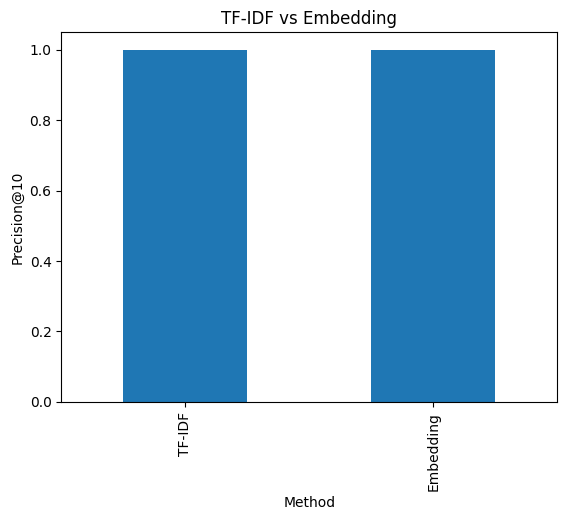

In [77]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Method",
    y="Precision@10",
    kind="bar",
    legend=False
)

plt.ylabel("Precision@10")
plt.title("TF-IDF vs Embedding")
plt.show()